<a href="https://colab.research.google.com/github/dcthyun0308/ESAA/blob/main/ESAA_OB_week04_F.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 행렬 분해를 이용한 잠재 요인 협업 필터링 실습

- SGD 기반의 행렬 분해를 구현하고 이를 기반으로 사용자에게 영화를 추천해 보자.
- 잠재 요인 협업 필터링 절의 확률적 경사 하강법을 이용한 행렬 분해에서 예제 코드를 활용해서 행렬 분해 로직 부분을 함수로 만들자.

In [3]:
import numpy as np

def get_rmse(R, P, Q, non_zeros):
    error = 0
    for i, j, r in non_zeros:
        pred = np.dot(P[i, :], Q[j, :].T)
        error += pow(r - pred, 2)
    rmse = np.sqrt(error / len(non_zeros))
    return rmse

In [4]:
def matrix_factorization(R, K, steps=200, learning_rate=0.01, r_lambda = 0.01):
  num_users, num_items = R.shape
  # P와 Q 매트릭스의 크기를 지정하고 정규 분포를 가진 랜덤한 값으로 입력합니다.
  np.random.seed(1)
  P = np.random.normal(scale=1./K, size=(num_users,K))
  Q = np.random.normal(scale=1./K, size=(num_items,K))

  # R > 0인 행 위치, 열 위치, 값을 non_zeros 리스트 객체에 저장.
  non_zeros = [ (i,j,R[i,j]) for i in range(num_users) for j in range(num_items) if R[i,j]>0]

  # SGD 기법으로 P와 Q 매트릭스를 계속 업데이트.
  for step in range(steps):
    for i, j, r in non_zeros:
      # 실제 값과 예측 값의 차이인 오류 값 구함
      eij = r - np.dot(P[i,:], Q[j,:].T)
      # Regularization을 반영한 SGD 업데이트 공식 적용
      P[i,:] = P[i,:] + learning_rate*(eij * Q[j,:] - r_lambda*P[i,:])
      Q[j,:] = Q[j,:] + learning_rate*(eij * P[i,:] - r_lambda*Q[j,:])

    rmse = get_rmse(R,P,Q,non_zeros)
    if (step & 10) == 0:
      print("### iteration step: ", step, "rmse: ", rmse)

  return P, Q

먼저 영화 평점 행렬 데이터를 새롭게 DataFrame으로 로딩한 뒤에 다시 사용자-아이템 평점 행렬로 만들자.

In [5]:
import pandas as pd
import numpy as np

movies = pd.read_csv('movies.csv')
ratings = pd.read_csv('ratings.csv')
ratings = ratings[['userId','movieId','rating']]
ratings_matrix = ratings.pivot_table('rating',index='userId',columns='movieId')

# title 칼럼을 얻기 위해 movies와 조인 수행
rating_movies = pd.merge(ratings, movies, on='movieId')
# columns='title'로 title 칼럼으로 pivot 수행.
ratings_matrix = rating_movies.pivot_table('rating', index='userId', columns='title')

다시 만들어진 사용자-아이템 평점 행렬을 matrix_factorization() 함수를 이용해 행렬 분해하자. 수행 시간이 오래 걸리므로 SGD 반복 횟수인 steps는 200회만 지정하자. 잠재 요인 차원 K는 50, 학습률과 L2 Regularization 계수는 모두 0.01로 설정하고 수행하자.

In [6]:
P, Q = matrix_factorization(ratings_matrix.values, K=50, steps=200, learning_rate=0.01,
                            r_lambda=0.01)
pred_matrix = np.dot(P, Q.T)

### iteration step:  0 rmse:  2.9023619751337115
### iteration step:  1 rmse:  1.5381600369187958
### iteration step:  4 rmse:  0.9531506202657996
### iteration step:  5 rmse:  0.8964840607049039
### iteration step:  16 rmse:  0.5932957947397758
### iteration step:  17 rmse:  0.571577136398696
### iteration step:  20 rmse:  0.5115539026853438
### iteration step:  21 rmse:  0.49354799608250016
### iteration step:  32 rmse:  0.35356488365829136
### iteration step:  33 rmse:  0.3448472988337887
### iteration step:  36 rmse:  0.3215421798708517
### iteration step:  37 rmse:  0.3146270364308641
### iteration step:  48 rmse:  0.25913921753850744
### iteration step:  49 rmse:  0.25550058673548565
### iteration step:  52 rmse:  0.24558236871730746
### iteration step:  53 rmse:  0.24257527886426072
### iteration step:  64 rmse:  0.21684277951932898
### iteration step:  65 rmse:  0.21502175010136534
### iteration step:  68 rmse:  0.2099467031199095
### iteration step:  69 rmse:  0.20837348009118

더 쉽게 영화 아이템 칼럼을 이해하기 위해 반환된 예측 사용자-아이템 평점 행렬을 영화 타이틀을 칼럼명으로 가지는 DataFrame으로 변경하자.

In [7]:
ratings_pred_matrix = pd.DataFrame(data=pred_matrix, index=ratings_matrix.index,
                                   columns=ratings_matrix.columns)
ratings_pred_matrix.head(3)

title,'71 (2014),'Hellboy': The Seeds of Creation (2004),'Round Midnight (1986),'Salem's Lot (2004),'Til There Was You (1997),'Tis the Season for Love (2015),"'burbs, The (1989)",'night Mother (1986),(500) Days of Summer (2009),*batteries not included (1987),...,Zulu (2013),[REC] (2007),[REC]² (2009),[REC]³ 3 Génesis (2012),anohana: The Flower We Saw That Day - The Movie (2013),eXistenZ (1999),xXx (2002),xXx: State of the Union (2005),¡Three Amigos! (1986),À nous la liberté (Freedom for Us) (1931)
userId,,,,,,,,,,,,,,,,,,,,,
1,3.055084,4.092018,3.564130,4.502167,3.981215,1.271694,3.603274,2.333266,5.091749,3.972454,...,1.402608,4.208382,3.705957,2.720514,2.787331,3.475076,3.253458,2.161087,4.010495,0.859474
2,3.170119,3.657992,3.308707,4.166521,4.311890,1.275469,4.237972,1.900366,3.392859,3.647421,...,0.973811,3.528264,3.361532,2.672535,2.404456,4.232789,2.911602,1.634576,4.135735,0.725684
3,2.307073,1.658853,1.443538,2.208859,2.229486,0.780760,1.997043,0.924908,2.970700,2.551446,...,0.520354,1.709494,2.281596,1.782833,1.635173,1.323276,2.887580,1.042618,2.293890,0.396941


이렇게 만들어진 예측 사용자-아이템 평점 행렬 정보를 이용해 개인화된 영화 추천을 해 보자.

In [8]:
# 사용자 9번 영화추천
def get_unseen_movies(ratings_matrix, userId):
    # userId로 입력받은 사용자의 모든 영화 정보를 추출해 Series로 반환함.
    # 반환된 user_rating은 영화명(title)을 인덱스를 가지는 Series 객체임.
    user_rating = ratings_matrix.loc[userId, :]

    #user_rating이 0보다 크면 기존에 관람한 영화임. 대상 인덱스를 추출해 list 객체로 만듦.
    already_seen = user_rating[ user_rating > 0].index.tolist()

    # 모든 영화명을 list 객체로 만듦.
    movies_list = ratings_matrix.columns.tolist()

    # list comporehension으로 already_seen에 해당하는 영화는 movies_list에서 제외함.
    unseen_list = [ movie for movie in movies_list if movie not in already_seen]
    return unseen_list

def recomm_movie_by_userid(pred_df, userId, unseen_list, top_n = 10):
    # 예측 평점 DataFrame에서 사용자id 인덱스와 unseen_list로 들어온 영화명 칼럼을 추출해
    # 가장 예측 평점이 높은 순으로 정렬함.
    recomm_movies = pred_df.loc[userId, unseen_list].sort_values(ascending=False)[:top_n]
    return recomm_movies

In [9]:
# 사용자가 관람하지 않은 영화명 추출
unseen_list = get_unseen_movies(ratings_matrix, 9)

# 잠재 요인 협업 필터링으로 영화 추천
recomm_movies = recomm_movie_by_userid(ratings_pred_matrix, 9, unseen_list, top_n=10)

# 평점 데이터를 DataFrame으로 생성
recomm_movies = pd.DataFrame(data=recomm_movies.values, index=recomm_movies.index,
                             columns=['pred_score'])
recomm_movies

,pred_score
title,
Rear Window (1954),5.704612
"South Park: Bigger, Longer and Uncut (1999)",5.451100
Rounders (1998),5.298393
Blade Runner (1982),5.244951
Roger & Me (1989),5.191962
Gattaca (1997),5.183179
Ben-Hur (1959),5.130463
Rosencrantz and Guildenstern Are Dead (1990),5.087375
"Big Lebowski, The (1998)",5.038690


# 파이썬 추천 시스템 패키지 - Surprise

## Surprise 패키지 소개
- Surprise는 파이썬 기반에서 사이킷런과 유사한 API와 프레임워크를 제공하자. 따라서 추천 시스템의 전반적인 알고리즘을 이해하고 사이킷런 사용 경험이 있으면 쉽게 사용할 수 있음.

In [23]:
! pip install scikit-surprise

In [24]:
#! conda install -c conda-forge scikit-surprise

## Surprise를 이용한 추천 시스템 구축
- 간단한 예제를 통해 Surprise 패키지의 개략적인 사용법을 익혀보자. 예제는 추천 데이터를 학습용과 테스트용 데이터 세트로 분리한 뒤 SVD 행렬 분해를 통한 잠재 요인 협업 필터링을 수행하자.

In [1]:
!pip uninstall numpy -y
!pip install numpy==1.26.6
!pip install scikit-surprise --upgrade --no-deps

Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
ERROR: Ignored the following yanked versions: 2.4.0
ERROR: Ignored the following versions that require a different python version: 1.21.2 Requires-Python >=3.7,<3.11; 1.21.3 Requires-Python >=3.7,<3.11; 1.21.4 Requires-Python >=3.7,<3.11; 1.21.5 Requires-Python >=3.7,<3.11; 1.21.6 Requires-Python >=3.7,<3.11
ERROR: Could not find a version that satisfies the requirement numpy==1.26.6 (from versions: 1.3.0, 1.4.1, 1.5.0, 1.5.1, 1.6.0, 1.6.1, 1.6.2, 1.7.0, 1.7.1, 1.7.2, 1.8.0, 1.8.1, 1.8.2, 1.9.0, 1.9.1, 1.9.2, 1.9.3, 1.10.0.post2, 1.10.1, 1.10.2, 1.10.4, 1.11.0, 1.11.1, 1.11.2, 1.11.3, 1.12.0, 1.12.1, 1.13.0, 1.13.1, 1.13.3, 1.14.0, 1.14.1, 1.14.2, 1.14.3, 1.14.4, 1.14.5, 1.14.6, 1.15.0, 1.15.1, 1.15.2, 1.15.3, 1.15.4, 1.16.0, 1.16.1, 1.16.2, 1.16.3, 1.16.4, 1.16.5, 1.16.6, 1.17.0, 1.17.1, 1.17.2, 1.17.3, 1.17.4, 1.17.5, 1.18.0, 1.18.1, 1.18.2, 1.18.3, 1.18.4, 1.18.5, 1.19.0, 1.1

In [2]:
from surprise import SVD
from surprise import Dataset
from surprise import accuracy
from surprise.model_selection import train_test_split

Surprise 패키지의 train_test_split() API를 이용해 학습 데이터 세트와 테스트 데이터 세트로 분리해보자.

In [10]:
data = Dataset.load_builtin('ml-100k')
# 수행 시마다 동일하게 데이터를 분할하기 위해 random_state 값 부여
trainset, testset = train_test_split(data, test_size=.25, random_state=0)

Dataset ml-100k could not be found. Do you want to download it? [Y/n] Y
Trying to download dataset from https://files.grouplens.org/datasets/movielens/ml-100k.zip...
Done! Dataset ml-100k has been saved to /root/.surprise_data/ml-100k


먼저 algo = SVD()와 같이 알고리즘 객체를 생성하고 이 알고리즘 객체에 fit(학습 데이터 세트)을 수행해 학습 데이터 세트 기반으로 추천 알고리즘을 학습하자.

In [11]:
algo = SVD(random_state=0)
algo.fit(trainset)

학습된 추천 알고리즘을 기반으로 테스트 데이터 세트에 대해 추천을 수행하자.

In [12]:
predictions = algo.test(testset)
print('prediction type: ', type(predictions), 'size: ', len(predictions))
print('prediction 결과의 최초 5개 추출')
predictions[:5]

prediction type:  <class 'list'> size:  25000
prediction 결과의 최초 5개 추출


[Prediction(uid='120', iid='282', r_ui=4.0, est=3.5114147666251547, details={'was_impossible': False}),
 Prediction(uid='882', iid='291', r_ui=4.0, est=3.573872419581491, details={'was_impossible': False}),
 Prediction(uid='535', iid='507', r_ui=5.0, est=4.033583485472447, details={'was_impossible': False}),
 Prediction(uid='697', iid='244', r_ui=5.0, est=3.8463639495936905, details={'was_impossible': False}),
 Prediction(uid='751', iid='385', r_ui=4.0, est=3.1807542478219157, details={'was_impossible': False})]

다음은 3개의 Prediction 객체에서 uid, iid, est 속성을 추출한 예제.

In [13]:
[(pred.uid, pred.iid, pred.est) for pred in predictions[:3]]

[('120', '282', 3.5114147666251547),
 ('882', '291', 3.573872419581491),
 ('535', '507', 4.033583485472447)]

이번에는 Surprise 패키지의 다른 추천 예측 메서드인 predict()를 이용해 추천 예측을 해보자.

In [14]:
# 사용자 아이디, 아이템 아이디는 문자열로 입력해야 함.
uid = str(196)
iid = str(302)
pred = algo.predict(uid, iid)
print(pred)

user: 196        item: 302        r_ui = None   est = 4.49   {'was_impossible': False}


테스트 데이터 세트를 이용해 추천 예측 평점과 실제 평점과의 차이를 평가해 보자. accuracy 모듈의 rmse()를 이용해 RMSE 평가 결과를 확인해 보자.

In [15]:
accuracy.rmse(predictions)

RMSE: 0.9467


0.9466860806937948

## Surprise 주요 모듈 소개

### OS 파일 데이터를 Surprise 데이터 세트로 로딩

판다스 DataFrame의 to_csv() 함수를 이용해 간단하게 이 칼럼 헤더를 삭제하고 새로운 파일인 ratings_noh.csv로 저장하자.

In [16]:
import pandas as pd

ratings = pd.read_csv('ratings.csv')
# ratings_noh.csv 파일로 언로드 시 인덱스와 헤더를 모두 제거한 새로운 파일 생성.
ratings.to_csv('ratings_noh.csv', index=False, header=False)

In [17]:
from surprise import Reader

reader = Reader(line_format='user item rating timestamp', sep=',', rating_scale=(0.5,5))
data = Dataset.load_from_file('ratings_noh.csv', reader=reader)

이제 SVD 행렬 분해 기법을 이용해 추천을 예측해 보자.

In [18]:
trainset, testset = train_test_split(data,test_size=.25, random_state=0)

# 수행 시마다 동일한 결과를 도출하기 위해 random_state 설정
algo = SVD(n_factors=50, random_state=0)

# 학습 데이터 세트로 학습하고 나서 테스트 데이터 세트로 평점 예측 후 RMSE 평가
algo.fit(trainset)
predictions = algo.test(testset)
accuracy.rmse(predictions)

RMSE: 0.8682


0.8681952927143516

### 판다스 DataFrame에서 Surprise 데이터 세트로 로딩

In [19]:
import pandas as pd
from surprise import Reader, Dataset

ratings = pd.read_csv('ratings.csv')
reader = Reader(rating_scale=(0.5, 5.0))

# ratings DataFrame에서 칼럼은 사용자 아이디, 아이템 아이디, 평점 순서를 지켜야 합니다.
data = Dataset.load_from_df(ratings[['userId', 'movieId', 'rating']],reader)
trainset, testset = train_test_split(data,test_size=.25, random_state=0)

algo = SVD(n_factors=50, random_state=0)
algo.fit(trainset)
predictions = algo.test(testset)
accuracy.rmse(predictions)

RMSE: 0.8682


0.8681952927143516

## Surprise 추천 알고리즘 클래스

Surprise에서 추천 예측을 위해 자주 사용되는 추천 알고리즘 클래스는 다음과 같다.

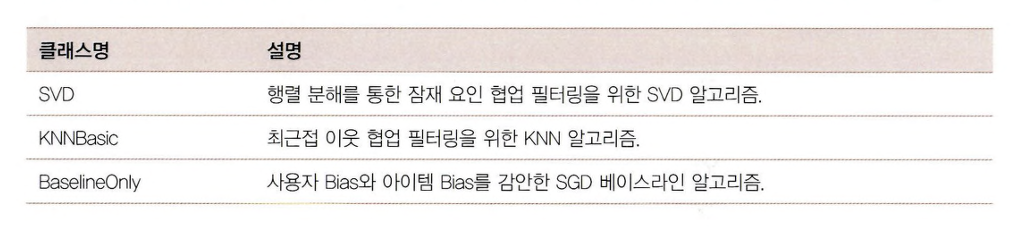

SVD 클래스의 입력 파라미터는 다음과 같다.

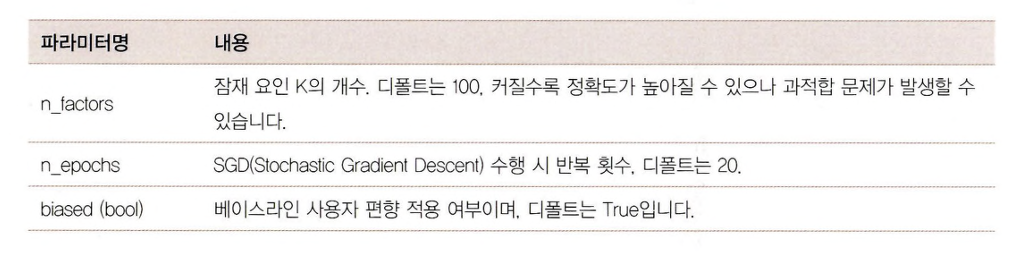

## 베이스라인 평점
- 보통 베이스라인 평점은 전체 평균 평점 + 사용자 편향 점수 + 아이템 편향 점수 공식으로 계산됨.

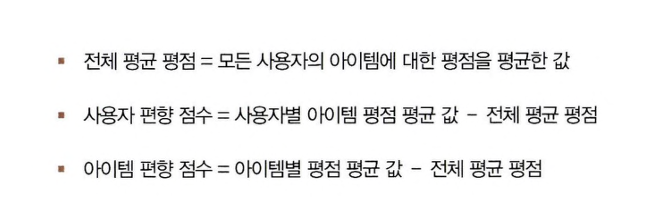

## 교차 검증과 하이퍼 파라미터 튜닝

다음 예제에서는 cross_validate()를 이용해 ratings.csv를 DataFrame으로 로딩한 데이터 5개의 학습/검증 폴드 데이터 세트로 분리해 교차 검증을 수행하고 RMSE, MAE로 성능 평가를 진행하자.

In [20]:
from surprise.model_selection import cross_validate

# 판다스 DataFrame에서 Surprise 데이터 세트로 데이터 로딩
ratings = pd.read_csv('ratings.csv') # reading data in pandas df
reader = Reader(rating_scale=(0.5, 5.0))
data = Dataset.load_from_df(ratings[['userId', 'movieId', 'rating']], reader)

algo = SVD(random_state=0)
cross_validate(algo, data, measures=['RMSE', 'MAE'], cv=5, verbose=True)

Evaluating RMSE, MAE of algorithm SVD on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    0.8688  0.8809  0.8679  0.8758  0.8726  0.8732  0.0048  
MAE (testset)     0.6697  0.6765  0.6686  0.6715  0.6695  0.6712  0.0028  
Fit time          1.59    1.50    1.52    1.48    1.52    1.52    0.04    
Test time         0.11    0.11    0.11    0.23    0.11    0.14    0.05    


{'test_rmse': array([0.86875695, 0.88092589, 0.86790862, 0.87578182, 0.87258328]),
 'test_mae': array([0.66974362, 0.67645239, 0.66859186, 0.67147973, 0.6695167 ]),
 'fit_time': (1.5926721096038818,
  1.503054141998291,
  1.5162303447723389,
  1.4798917770385742,
  1.5196566581726074),
 'test_time': (0.1109323501586914,
  0.11405181884765625,
  0.1120610237121582,
  0.23095202445983887,
  0.11169815063476562)}

Cv가 3일 때의 최적 하이퍼 파라미터를 도출해 보자.

In [21]:
from surprise.model_selection import GridSearchCV

# 최넉화할 파라미터를 딕셔너리 형태로 지정.
param_grid = {'n_epochs':[20,40,60], 'n_factors':[50,100,200]}

# CV를 3개 폴드 세트로 지정, 성능 평가는 rmse, mse로 수행하도록 GridSearchCV 구성
gs = GridSearchCV(SVD, param_grid, measures=['rmse', 'mae'], cv=3)
gs.fit(data)

# 최고 RMSE Evaluation 점수와 그떄의 하이퍼 파라미터
print(gs.best_score['rmse'])
print(gs.best_params['rmse'])

0.8776388808022743
{'n_epochs': 20, 'n_factors': 50}


## Surprise를 이용한 개인화 영화 추천 시스템 구축

In [22]:
# 다음 코드는 train_test_split()으로 분리되지 않는 데이터 세트에 fit()을 호출해 오류가 발생합니다.
data = Dataset.load_from_df(ratings[['userId', 'movieId', 'rating']], reader)
algo = SVD(n_factors=50, random_state=0)
algo.fit(data)

AttributeError: 'DatasetAutoFolds' object has no attribute 'n_users'

데이터 세트 전체를 학습 데이터로 사용하려면 DatasetAutoFolds 클래스를 이용하면 됨.

In [23]:
from surprise.dataset import DatasetAutoFolds

reader = Reader(line_format='user item rating timestamp', sep=',', rating_scale=(0.5, 5))
# DatasetAutoFolds 클래스를 ratings_noh.csv 파일 기반으로 생성.
data_folds = DatasetAutoFolds(ratings_file='ratings_noh.csv', reader=reader)

# 전체 데이터를 학습 데이터로 생성함.
trainset = data_folds.build_full_trainset()

SVD를 이용해 학습을 수행하자.

In [24]:
algo = SVD(n_epochs=20, n_factors=50, random_state=0)
algo.fit(trainset)

특정 사용자는 userld = 9인 사용자 지정하자. 간단하게 Surprise 패키지의 API를 이용해 예제를 수행하기 위해 userld 9가 아직 평점을 매기지 않은 영화를 movieId 42로 선정한 뒤 예측 평점을 계산해보자.

In [25]:
# 영화에 대한 상세 속성 정보 DataFrame 로딩
movies = pd.read_csv('movies.csv')

# userld=9의 movieId 데이터를 추출해 movieId=42 데이터가 있는지 확인.
movieIds = ratings[ratings['userId']==9] ['movieId']
if movieIds[movieIds==42].count() == 0:
  print('사용자 아이디 9는 영화 아이디 42의 평점 없음')

print(movies[movies['movieId']==42])

사용자 아이디 9는 영화 아이디 42의 평점 없음
    movieId                   title              genres
38       42  Dead Presidents (1995)  Action|Crime|Drama


이 movieId 42인 영화에 대해서 userld 9 사용자의 추천 예상 평점은 predict() 메서드를 이용하면 알 수 있음. 학습되니 SVD 객체에서 predict() 메서드 내에 userld와 movieId 값을 입력해주면 됨.

In [26]:
uid = str(9)
iid = str(42)

pred = algo.predict(uid, iid, verbose=True)

user: 9          item: 42         r_ui = None   est = 3.13   {'was_impossible': False}


In [27]:
def get_unseen_surprise(ratings, movies, userId):
  # 입력값으로 들어온 userid에 해당하는 사용자가 평점을 매긴 모든 영화를 리스트로 생성
  seen_movies = ratings[ratings['userId']== userId]['movieId'].tolist()

  # 모든 영화의 movield를 리스트로 생성.
  total_movies = movies['movieId'].tolist()

  # 모든 영화의 movieId 중 이미 평점을 매긴 영화의 movieId를 제외한 후 리스트로 생성
  unseen_movies = [movie for movie in total_movies if movie not in seen_movies]
  print('평점 매긴 영화 수:', len(seen_movies), '추천 대상 영화 수:', len(unseen_movies),
        '전체 영화 수:', len(total_movies))
  return unseen_movies

unseen_movies = get_unseen_surprise(ratings, movies, 9)

평점 매긴 영화 수: 46 추천 대상 영화 수: 9696 전체 영화 수: 9742


recomm_movie_by_surprise()는 추천 대상 영화 모두를 대상으로 추천 알고리즘 객체의 predict() 메서드를 호출하고 그 결과인 Prediction 객체를 리스트 객체로 저장함.

In [28]:
def recomm_movie_by_surprise(algo, userId, unseen_movies, top_n=10):
  # 알고리즘 객체의 predictO 메서드를 평점이 없는 영화에 반복 수행한 후 결과를 list 객체로 저장
  predictions = [algo.predict(str(userId), str(movieId)) for movieId in unseen_movies]

  # predictions list 객체는 surprise의 Predictions 객체를 원소로 가지고 있음.
  # [Prediction(uid=,9', iid='1 est=3.69), Prediction(uid='9', iid='2', est=2.98),,,,]
  # 이를 est 값으로 정렬하기 위해서 아래의 sortkey_est 함수를 정의함.
  # sortkey.est 함수는 list 객체의 sort() 함수의 키 값으로 사용되어 정렬 수행.
  def sortkey_est(pred):
    return pred.est

  # sortkey_est( ) 반환값의 내림 차순으로 정렬 수행하고 top_n개의 최상위 값 추출.
  predictions.sort(key=sortkey_est, reverse=True)
  top_predictions= predictions[:top_n]

  # top_n으로 추출된 영화의 정보 추출. 영화 아이디, 추천 예상 평점, 제목 추출
  top_movie_ids = [ int(pred.iid) for pred in top_predictions]
  top_movie_rating = [ pred.est for pred in top_predictions]
  top_movie_titles = movies[movies.movieId.isin(top_movie_ids)]['title']
  top_movie_preds = [ (id, title, rating) for id, title, rating in \
                     zip(top_movie_ids, top_movie_titles, top_movie_rating)]
  return top_movie_preds

unseen_movies = get_unseen_surprise(ratings, movies, 9)
top_movie_preds = recomm_movie_by_surprise(algo, 9, unseen_movies, top_n=10)

print('##### Top-10 추천 영화 리스트 #####')
for top_movie in top_movie_preds:
  print(top_movie[1],":", top_movie[2])

평점 매긴 영화 수: 46 추천 대상 영화 수: 9696 전체 영화 수: 9742
##### Top-10 추천 영화 리스트 #####
Usual Suspects, The (1995) : 4.306302135700814
Star Wars: Episode IV - A New Hope (1977) : 4.281663842987387
Pulp Fiction (1994) : 4.278152632122759
Silence of the Lambs, The (1991) : 4.226073566460876
Godfather, The (1972) : 4.1918097904381995
Streetcar Named Desire, A (1951) : 4.154746591122657
Star Wars: Episode V - The Empire Strikes Back (1980) : 4.122016128534504
Star Wars: Episode VI - Return of the Jedi (1983) : 4.108009609093436
Goodfellas (1990) : 4.083464936588478
Glory (1989) : 4.07887165526957
